# Data assimilation 2

Within this lecture, we continue our discussion of data assimilation. Last time, we saw how Bayesian methods can be used to 
provide a complete solution of the data assimilation problem for deterministic and finite-dimensional dynamical systems. 
The issue, however, is that the computational cost of the full method is too high to be applied directly within 
realistic applications. Our focus in this lecture is on approximate forms for the full Bayesian solution that are computationally tractable
and so can be applied to weather forecasting and other climatological applications.

### Review of the Bayesian approach

We consider a dynamical system on an $m$-dimensional state space, $\mathbb{R}^{m}$, and write 
$\mathbf{x}$ for a state vector. The dynamics is governed by an evolution equation of the form
$$
\frac{\mathrm{d}\mathbf{x}}{\mathrm{d}t} = \mathbf{f}(\mathbf{x}), 
$$
with $\mathbf{f}(\mathbf{x})$ known as the dynamical rule. Given an initial condition, 
$\mathbf{x}(0) = \mathbf{x}_{0}$, this equation has a unique solution for all times. 
We write $\bm{\Phi}$ for the flow of the system, this being the mapping such that 
$\bm{\Phi}(\mathbf{x}_{0},t)$ is the state at time, $t$, associated with the initial condition, $\mathbf{x}_{0}$.
For convenience we write 
$$
\bm{\Phi}_{t}(\mathbf{x}_{0}) = \bm{\Phi}(\mathbf{x},t)
$$
for the induced mapping on the state space at time, $t$, which 
has the inverse 
$$
\bm{\Phi}_{t}^{-1}(\mathbf{x}) = \bm{\Phi}(\mathbf{x},-t).
$$

Suppose that at a set of times, $t_{1}, \dots, t_{n}$, we have noisy partial observations
$$
\mathbf{y}_{i} = \mathbf{g}_{i}[\mathbf{x}(t)] + \mathbf{z}_{i}, 
$$
where the $\mathbf{g}_{i}:\mathbf{R}^{m}\rightarrow \mathbb{R}^{n_{i}}$ are observation functions that map to lower-dimensional observation spaces,
and $\mathbf{z}_{i}$ are observational errors drawn from known error distributions. Our aim is to forecast the future 
state of the system for $t > t_{n}$. 

Within the Bayesian framework, we start with a prior probability distribution, $\pi_{0}$, on the initial 
state with PDF, $p_{0}$. To construct our forecast we follow 
a sequence of **prediction-analysis loop**:

At the $i$-th **prediction** step, assume that our knowledge of the state at time $t_{i-1}$ is expressed through a distribution, $\tilde{\pi}_{i-1}$. We push forward this distribution under the dynamics to obtain the prior distribution 
$$
\pi_{i} = \tilde{\pi}_{i-1} \circ \bm{\Phi}_{t_{i}-t_{i-1}}^{-1}, 
$$
for the state at time, $t_{i}$. 

The $i$-th **analysis** step then applies Bayes theorem to update the prior, $\pi_{i}$, in light of the 
observations available at this time. In terms of the associated PDFs, this update takes the form
$$
\tilde{p}_{i}(\mathbf{x})  = \frac{q_{i}[\mathbf{y}_{i} - \mathbf{g}_{i}(\mathbf{x})] p_{i}(\mathbf{x})}{\int_{\mathbb{R}^{m}} q_{i}[\mathbf{y}_{i} - \mathbf{g}_{i}(\mathbf{x})] p_{i}(\mathbf{x}) \,\mathrm{d}\mathbf{x}}, 
$$
where $p_{i}$ is the prior PDF, $\tilde{p}_{i}$ the posterior PDF, and $q_{i}$ the PDF for the corresponding error distribution.

The while process is started with a prior distribution, $\pi_{0}$ for the initial state, and having assimilated all the observations
we arrive at a posterior distribution, $\tilde{\pi}_{t_{n}}$ at the final observation time. Our forecast
is then found by pushing forward $\tilde{\pi}_{t_{n}}$ to later times.

We can also perform a **reanalysis** in which  $\pi_{t_{n}}$ is pushed back to the initial time
to arrive at a posterior distribution, $\tilde{\pi}_{0}$, on the initial state. Using $\tilde{\pi}_{0}$, 
the state of the system over the observation period can also be reconstructed.






## Linear data assimilation problems

The aim of this section is to show that within an important special case, the full Bayesian solution of the data
assimilation problem can be obtained in a simpler manner. This special case then forms the basis for the more 
general approximate methods discussed below. 

### The flow of a linear dynamical system

Recall that a dynamical system is linear if its evolution equation takes the form
$$
\frac{\mathrm{d}\mathbf{x}}{\mathrm{d}t} = \mathbf{A}\mathbf{x}, 
$$
with $\mathbf{A}$ a matrix that maps the state space to itself. The solution of this equation subject to 
the initial condition $\mathbf{x}(0) = \mathbf{x}_{0}$ can be written
$$
\mathbf{x}(t) = \exp(\mathbf{A}t)\mathbf{x}_{0}, 
$$
where the exponential of a matrix is defined through its Taylor expansion
$$
\exp(\mathbf{A}) = \sum_{j=0}^{\infty} \frac{1}{j!}\mathbf{A}^{j}.
$$
The validity of the above solution can be verfied by differentiating the appropriate Taylor
series term by term.  It follows that the flow of a linear dynamical system takes the form
$$
\bm{\Phi}(\mathbf{x}_{0},t) = \exp( \mathbf{A} t)\mathbf{x}_{0}, 
$$
and hence the induced mapping, $\bm{\Phi}_{t}$, is linear, corresponding to the matrix, $\exp( \mathbf{A} t)$.

### Linearisation of a dynamical system about equilibrium

While some physical systems are linear, it is more usual for linear evolution equations to arise as 
an approximation to the full dynamics. 

An **equilibrium state**, $\mathbf{x}_{0}$, of a dynamical system is defined through the condition
$$
\mathbf{f}(\mathbf{x}_{0}) = \mathbf{0}.
$$
It is clear that if a system is in an equilibrium state at time, $t=0$, then it is in this state for all other times. 
With $\mathbf{x}_{0}$ an equilibrium state, consider the initial condition, $\mathbf{x}_{0} + \Delta\mathbf{x}_{0}$, with 
the perturbation term, $ \Delta\mathbf{x}_{0}$, suitably small. At a general time, $t$, we can then write the state as
$$
\mathbf{x}(t) = \mathbf{x}_{0} + \Delta \mathbf{x}(t) + o(\|\Delta\mathbf{x}_{0}\|).
$$
Putting this expansion into the evolution equation and retaining only first-order terms we obtain
$$
\frac{\mathrm{d}\Delta \mathbf{x}}{\mathrm{d}t} =  \frac{\partial \mathbf{f}}{\partial \mathbf{x}}(\mathbf{x}_{0}) \Delta \mathbf{x}, 
$$
which is subject to the initial condition, $\Delta\mathbf{x}(0) = \Delta \mathbf{x}_{0}$. This is a linear 
dynamical system for the perturbation about the equilibrium state. For sufficiently small initial 
perturbations, it should approximate well the system's full dynamics. Recalling the definition of the sensitivity matrix from last lecture, we note that
$$
\Delta\mathbf{x}(t) = \frac{\partial \Phi_{t}}{\partial \mathbf{x}_{0}}(\mathbf{x}_{0})\Delta \mathbf{x}_{0}.
$$


These ideas are readily applied to the pendulum system which has dynamical rule
$$
\mathbf{f}(\mathbf{x}) = \left(\begin{array}{c}
              \frac{1}{ml^{2}}p \\ - mgl \sin \theta
             \end{array}\right), 
$$
and hence
$$
\frac{\partial \mathbf{f}}{\partial \mathbf{x}}[\mathbf{x}(t)] = \left(\begin{array}{cc}
              0 && \frac{1}{ml^{2}} \\ - mgl \cos \theta && 0
             \end{array}\right).
$$
By inspection, an equilibrium state is
$$
\mathbf{x}_{0} = \left(\begin{array}{c}
             0 \\ 0
             \end{array}\right), 
$$
and the corresponding linearised evolution equation is
$$
\frac{\mathrm{d}}{\mathrm{d}t }\left(\begin{array}{c}
             \Delta \theta \\ \Delta p
             \end{array}\right) = \left(\begin{array}{cc}
              0 && \frac{1}{ml^{2}} \\ - mgl  && 0
             \end{array}\right) \left(\begin{array}{c}
             \Delta \theta \\ \Delta p
             \end{array}\right).
$$
For the pendulum system, there is a further equilbrium point at 
$$
\mathbf{x}_{0} = \left(\begin{array}{c}
             \pi \\ 0
             \end{array}\right). 
$$
It is clear physically that the first of these equilbrium states is stable, while the latter is not. The idea of stablility can be formalised, 
but we simply note that linearised approximations to the dynamics are only useful about a stable equilibrium. 

Within this [file](../data_assimilation/pendulum/single/physics.py) the dynamical rule for the and linearised pendulum system have been implemented, and in the code below we use then to investigate the accuracy of the linearisation for different initial perturbations. 

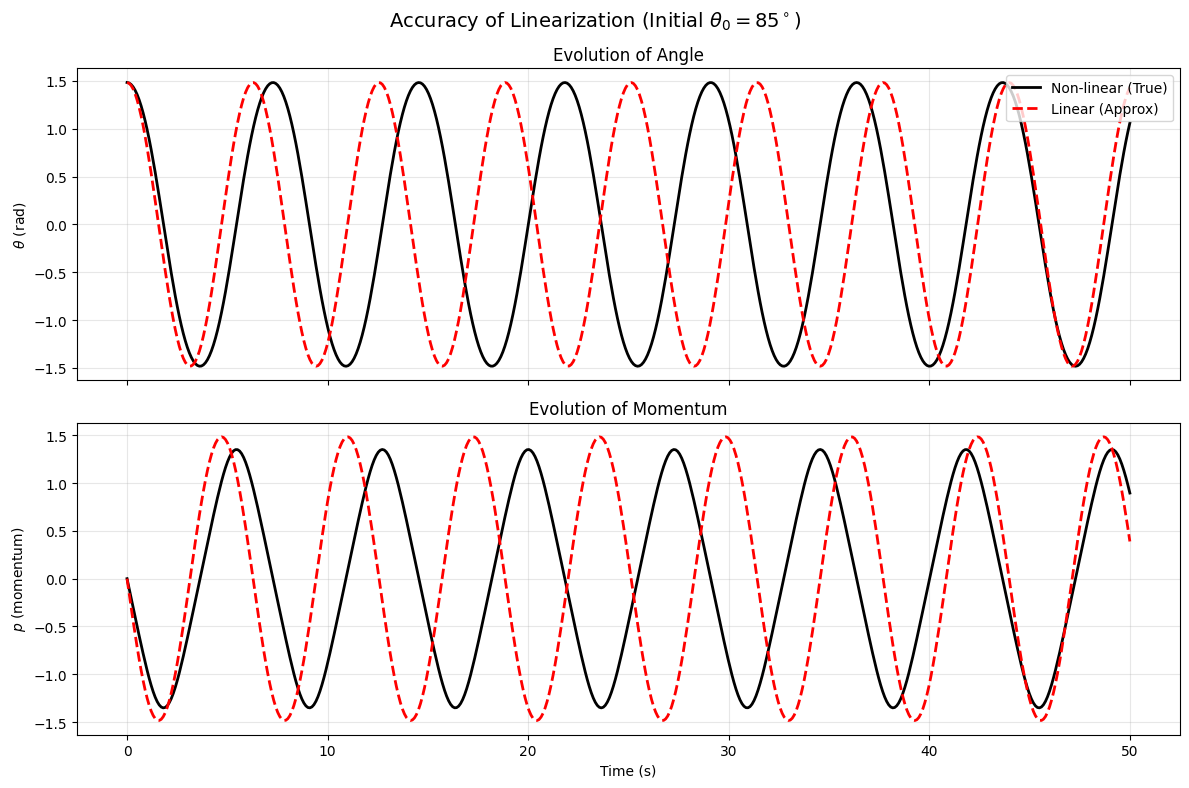

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from data_assimilation import pendulum

# Setup Parameters
params = {'L': 1.0, 'm': 1.0, 'g': 1.0}
t_points = np.linspace(0, 50, 500)

# Set the initial perturbation
theta_0 = 85
y0 = [np.deg2rad(theta_0), 0.0] 

# True Non-linear physics
sol_nl = pendulum.solve_trajectory(
    pendulum.single.physics.eom, y0, t_points, args=tuple(params.values())
)

# Linearization at equilibrium
sol_l = pendulum.solve_trajectory(
    pendulum.single.physics.eom_linear_static, y0, t_points, args=tuple(params.values())
)

# Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(t_points, sol_nl[0], 'k-', lw=2, label='Non-linear (True)')
ax1.plot(t_points, sol_l[0], 'r--', lw=2, label='Linear (Approx)')
ax1.set_ylabel(r"$\theta$ (rad)")
ax1.set_title("Evolution of Angle")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

ax2.plot(t_points, sol_nl[1], 'k-', lw=2, label='Non-linear (True)')
ax2.plot(t_points, sol_l[1], 'r--', lw=2, label='Linear (Approx)')
ax2.set_ylabel(r"$p$ (momentum)")
ax2.set_xlabel("Time (s)")
ax2.set_title("Evolution of Momentum")
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Accuracy of Linearization (Initial $\\theta_{{0}} = {theta_0}^\\circ$)', fontsize=14)
plt.tight_layout()
plt.show()


### Multivariate Gaussian distributions

A Gaussian distribution on $\mathbb{R}^{m}$ has PDF of the form
$$
p(\mathbf{x}) = \frac{1}{\sqrt{(2\pi)^{m} \det\mathbf{Q}}}
\mathrm{exp}\!\left[
    -\frac{1}{2}(\mathbf{x}-\overline{\mathbf{x}})^{T}\mathbf{Q}^{-1}(\mathbf{x}-\overline{\mathbf{x}})
    \right], 
$$
where $\overline{\mathbf{x}}$ is the **mean** value and $\mathbf{Q}$ is the **covariance**. The latter matrix needs to be symmetric and invertible
(Gaussian distributions with singular covariances can be defined but we do not need to consider this case). 

For a general PDF on $\mathbb{R}^{m}$, its **mean** is defined by 
$$
\overline{\mathbf{x}} = \int_{\mathbb{R}^{m}} \mathbf{x} \,p(\mathbf{x}) \,\mathrm{d}\mathbf{x}, 
$$
while its **covariance** is given by 
$$
\mathbf{Q} = \int_{\mathbb{R}^{m}} (\mathbf{x}-\overline{\mathbf{x}}) (\mathbf{x}-\overline{\mathbf{x}})^{T} p(\mathbf{x}) \,\mathrm{d}\mathbf{x}. 
$$
The mean and covariance calculated for a Gaussian distribution are precisely the parameters occurring within its PDF, and hence our terminology is consistent. 

In what follows, we write $\mathcal{N}(\overline{\mathbf{x}},\mathbf{Q})$ for the  Gaussian distribution with mean, $\overline{\mathbf{x}}$ and covariance, $\mathbf{Q}$.

The code below illustrates a Gaussian distribution on $\mathbb{R}^{2}$, showing its PDF along with a set of samples drawn from the distribution. The covariance can be varied to gain
a qualitative understanding of its significance. In particular, positive off-diagonal values imply a positive correlation between $\theta$ and $p$.


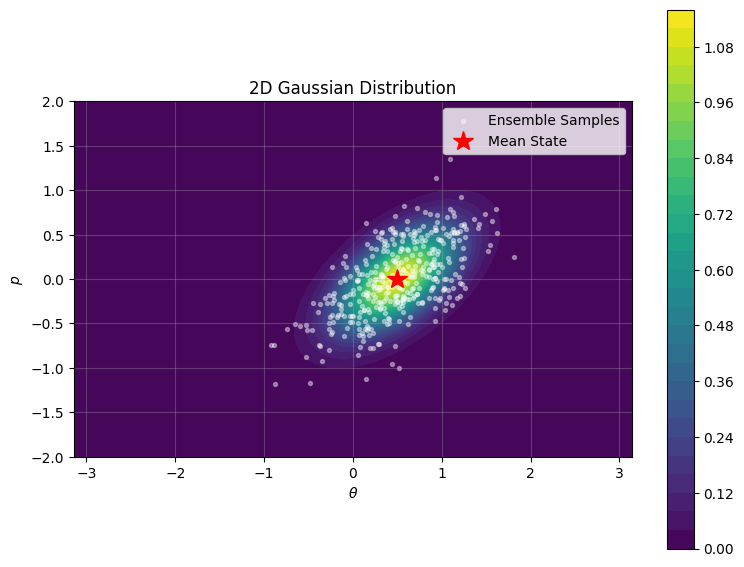

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Define Gaussian parameters
mean_state = np.array([0.5, 0.0])
cov_matrix = np.array([[0.2, 0.1], 
                       [0.1, 0.15]])

# Evaluate PDF on Grid (Replaces manual linspace/dstack/pdf calls)
pdf_func = pendulum.get_gaussian_pdf_func(mean_state, cov_matrix)
grid_limits = [(-np.pi, np.pi), (-2, 2)]

# Returns 1D axes and the Z grid (in 'ij' matrix indexing)
axes, Z = pendulum.evaluate_pdf_on_grid(pdf_func, grid_limits, resolution=100)

# Create 2D meshgrids to match Z for plotting
theta_grid, p_grid = np.meshgrid(*axes, indexing='ij')

# Generate Samples (Standard Numpy)
rng = np.random.default_rng()
samples = rng.multivariate_normal(mean_state, cov_matrix, size=400)

# Visualization
fig, ax = plt.subplots(figsize=(9, 7))

_, c1 = pendulum.single.plot_pdf(theta_grid, p_grid, Z, ax=ax, title="2D Gaussian Distribution")
fig.colorbar(c1, ax=ax)

ax.scatter(samples[:, 0], samples[:, 1], s=8, color='white', alpha=0.4, label='Ensemble Samples')
ax.plot(mean_state[0], mean_state[1], 'r*', markersize=15, label=r'Mean State')
ax.set_aspect("equal")
ax.legend()

plt.show()


### Push forward of a Gaussian under a linear flow

Recall from the last lecture that a distribtion $\pi$ with PDF, $p$, is transformed to 
$$
p_{t}(\mathbf{x}) = p_{0}[\bm{\Phi}_{t}^{-1}(\mathbf{x})]  \det\!\left\{
    \frac{\partial \Phi_{t}}{\partial \mathbf{x}_{0}}[\bm{\Phi}_{t}^{-1}(\mathbf{x})]\right\}, 
$$
under the flow of a dynamical system. When the dynamical system is linear and 
the initial distribution is Gaussian, the push forward of the distribution is also Gaussian and there
exist simple relationships between the means and covariances. 

For a linear dynamical system, we know that $\bm{\Phi}_{t}(\mathbf{x}_{0}) = \exp(\mathbf{A}t)\mathbf{x}_{0}$, and hence
$$
\frac{\partial \Phi_{t}}{\partial \mathbf{x}_{0}}[\bm{\Phi}_{t}^{-1}(\mathbf{x})] = \exp(\mathbf{A} t).
$$
 Applying the general transformation formula, it follows that the Gaussian distribution, $\mathcal{N}(\overline{\mathbf{x}},\mathbf{Q})$,
 becomes 
$$
p_{t}(\mathbf{x}) = \frac{1}{\sqrt{(2\pi)^{m} \det\mathbf{Q}}}
\mathrm{exp}\!\left[
    -\frac{1}{2}(\mathrm{e}^{-\mathbf{A}t}\mathbf{x}-\overline{\mathbf{x}})^{T}\mathbf{C}^{-1}
    (\mathrm{e}^{-\mathbf{A}t}\mathbf{x}-\overline{\mathbf{x}})
    \right]  \det \exp(\mathbf{A} t).
$$
Through a simple rearrangement, this can be written
$$
p_{t}(\mathbf{x}) = \frac{1}{\sqrt{(2\pi)^{m} \det\mathbf{Q}_{t}}}
\mathrm{exp}\!\left[
    -\frac{1}{2}(\mathbf{x}-\overline{\mathbf{x}}_{t})^{T}\mathbf{C}_{t}^{-1}
    (\mathbf{x}-\overline{\mathbf{x}}_{t})
    \right], 
$$
where we have defined 
$$
\overline{\mathbf{x}}_{t} = \exp(\mathbf{A} t)\overline{\mathbf{x}}, \quad 
\mathbf{Q}_{t} = \exp(\mathbf{A} t)\mathbf{Q} \exp(\mathbf{A} t)^{T}.
$$
Thus, the transformed distribution is still Gaussian, and its mean and covariance 
can be readily determined. 

The code below illustrates this idea. First, we perform the transformation of a Gaussian PDF using the general method from the last lecture, but 
applied to the linearised pendulum equations. Next, we transform the mean and covariance of the initial distribution using the above formulae, to verify
visualli that the results are the same. The necessary matrix exponential for the linearised pendulum system is obtain using the function `get_linear_propagator`
which can be seen [here](../data_assimilation/pendulum/single/physics.py).










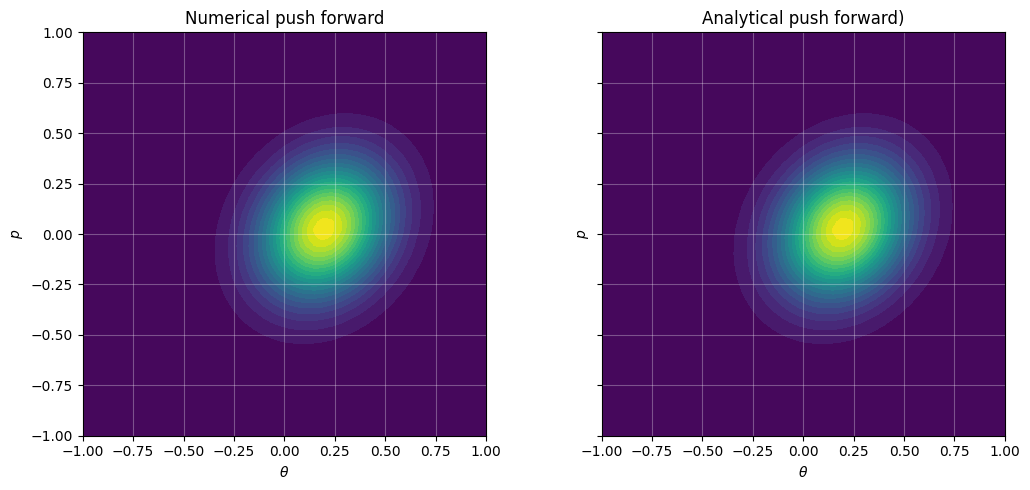

In [7]:

import numpy as np
import matplotlib.pyplot as plt
from data_assimilation import pendulum

# 1. Setup Parameters and Initial Correlated Prior
t_final = 25.0
params = {'L': 1.0, 'm': 1.0, 'g': 1.0}
mean_0 = np.array([0.2, 0.0]) 
cov_0 = np.array([[0.05, 0.01], [0.01, 0.05]]) 

# Create the prior function using the package's factory
prior_func = pendulum.core.get_gaussian_pdf_func(mean_0, cov_0)


# Linearized Numerical Push-forward 
theta_grid, p_grid, _, Z_numerical = pendulum.single.advect_pdf(
    prior_func, 
    t_final=t_final, 
    eom_func=pendulum.single.physics.eom_linear_static, 
    res=150, 
    **params
)

# Analytical Mapping 
Phi = pendulum.single.physics.get_linear_propagator(t_final, **params)
mean_t = Phi @ mean_0 
cov_t = Phi @ cov_0 @ Phi.T 
Z_analytical = pendulum.single.evaluate_gaussian_pdf(theta_grid, p_grid, mean_t, cov_t)

# 5. Visualization
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
titles = ["Numerical push forward", "Analytical push forward)"]
grids = [Z_numerical, Z_analytical]

for ax, data, title in zip(axes, grids, titles):    
    pendulum.single.plot_pdf(theta_grid, p_grid, data, ax=ax, title=title)
    
    ax.grid(True, color='white', alpha=0.3, zorder=10)
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

### Updating a Gaussian prior with Gaussian data

Suppose that our knowledge of the state, $\mathbf{x}$, is described by the Gaussian prior, 
$\mathcal{N}(\overline{\mathbf{x}},\mathbf{Q})$. We are then given a noisy partial observation 
$$
\mathbf{y} = \mathbf{G}\mathbf{x} + \mathbf{z}, 
$$
where $\mathbf{G}$ is a matrix that maps to a lower-dimensional observation space, and 
$\mathbf{z}$ is a random error with distribution $\mathcal{N}(\mathbf{0}, \mathbf{R})$;
not zero-means for the error distribution can be readily handled if required. 

Using Bayes theorem, we can then determine the posterior distribution 
for $\mathbf{x}$. In this case, the prior PDF takes the form
$$
p(\mathbf{x}) = \frac{1}{\sqrt{(2\pi)^{m} \det\mathbf{Q}}}
\mathrm{exp}\!\left[
    -\frac{1}{2}(\mathbf{x}-\overline{\mathbf{x}})^{T}\mathbf{Q}^{-1}(\mathbf{x}-\overline{\mathbf{x}})
    \right], 
$$
while the likelihood is given by
$$
q(\mathbf{y}-\mathbf{B}\mathbf{x}) = \frac{1}{\sqrt{(2\pi)^{m} \det\mathbf{R}}}
\mathrm{exp}\!\left[
    -\frac{1}{2}(\mathbf{y}-\mathbf{G}\mathbf{x})^{T}\mathbf{Q}^{-1}(\mathbf{y}-\mathbf{B}\mathbf{x})
    \right].
$$
The product of these two PDFs is clearly proportional to the exponential of a quadratic function 
of $\mathbf{x}$, with this suggesting that the posterior is also Gaussian. This is indeed true, 
and through some matrix algebra it can be shown that posterior distribution has mean
$$
\tilde{\overline{\mathbf{x}}} = \overline{\mathbf{x}} + \mathbf{Q}\mathbf{G}^{T}(\mathbf{G}\mathbf{Q}\mathbf{G}^{T} + \mathbf{R})^{-1}
(\mathbf{y} - \mathbf{G}\overline{\mathbf{x}}), 
$$
and covariance
$$
\tilde{\mathbf{Q}} = \mathbf{Q} - \mathbf{Q}\mathbf{G}^{T}(\mathbf{G}\mathbf{Q}\mathbf{G}^{T} + \mathbf{R})^{-1}
\mathbf{G}\mathbf{Q}.
$$

Within the code below, we perform an analysis step for an observation of $\theta$ using the general method of the last lecture and the above analytical 
formulae for the posterior mean and covariance. As can be seen, the results are identical. 

Analytical Posterior Mean: [0.78571429 0.07142857]
Analytical Posterior Cov:
[[0.00952381 0.00238095]
 [0.00238095 0.18809524]]


NameError: name 'mu_post_ana' is not defined

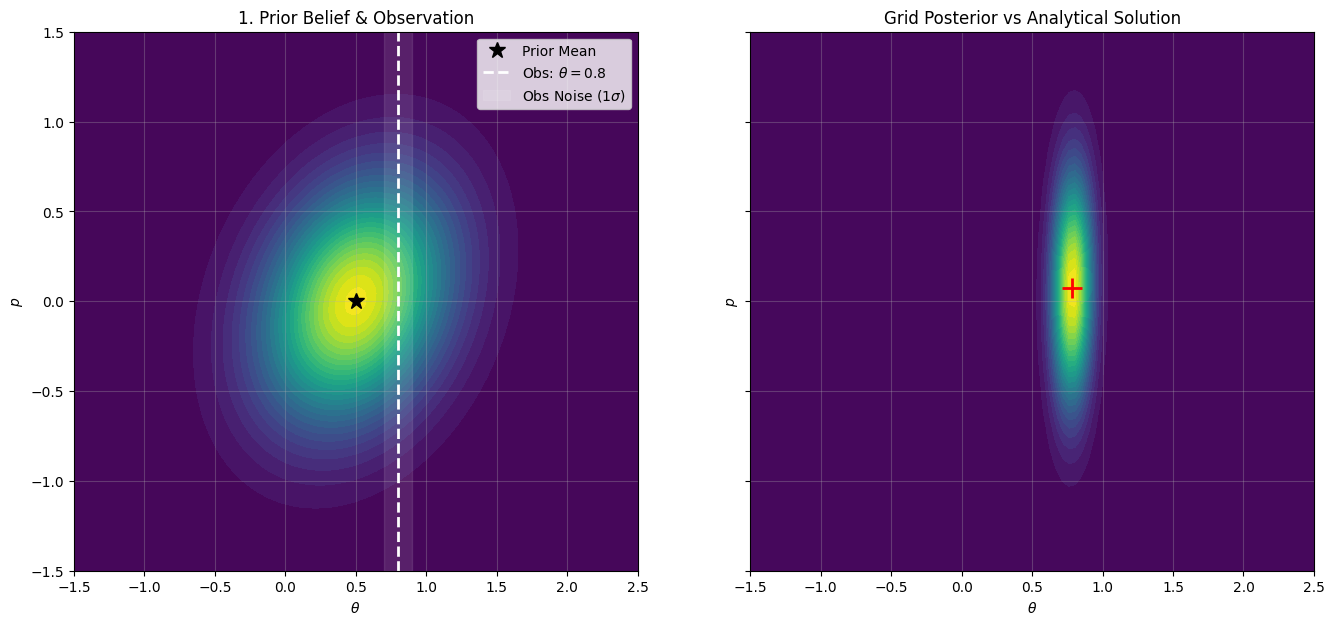

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Set the Gaussian prior
prior_mean = np.array([0.5, 0.0])
prior_cov  = np.array([[0.2, 0.05], 
                      [0.05, 0.2]])

# Set the observation
y_obs = np.array([0.8])
R     = np.array([[0.01]])
G     = np.array([[1.0, 0.0]])  

# Calcuate the posterior mean and covariance
S = G @ prior_cov @ G.T + R
K = prior_cov @ G.T @ np.linalg.inv(S)    
post_mean = prior_mean + K @ (y_obs - G @ prior_mean)
post_cov = (np.eye(2) - K @ G) @ prior_cov

print(f"Analytical Posterior Mean: {post_mean}")
print(f"Analytical Posterior Cov:\n{post_cov}")

# Prior PDF on a numerical grid
pdf_func = pendulum.get_gaussian_pdf_func(prior_mean, prior_cov)
grid_limits = [(-1.5, 2.5), (-1.5, 1.5)]
axes, prior = pendulum.evaluate_pdf_on_grid(pdf_func, grid_limits, resolution=100)

# Determine the likelihood
lik_model = pendulum.LinearGaussianLikelihood(y_obs, R, G)
theta_grid, p_grid = np.meshgrid(*axes, indexing='ij') 
state_grid = np.stack([theta_grid, p_grid], axis=-1)
lik_grid = lik_model.evaluate(state_grid)

# Compute Posterior on the grid
posterior, evidence = pendulum.bayesian_update(prior, lik_grid, axes)

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Plot the prior and show the observed angle

pendulum.single.plot_pdf(theta_grid, p_grid, prior, ax=ax1, title="1. Prior Belief & Observation")
ax1.plot(prior_mean[0], prior_mean[1], 'k*', ms=12, label='Prior Mean')
ax1.axvline(y_obs[0], color='white', linestyle='--', linewidth=2, label=f'Obs: $\\theta={y_obs[0]}$')
ax1.axvspan(y_obs[0] - np.sqrt(R[0,0]), y_obs[0] + np.sqrt(R[0,0]), color='white', alpha=0.1, label='Obs Noise ($1\sigma$)')
ax1.legend(loc='upper right')


# Plot the grid posterior 
pendulum.single.plot_pdf(theta_grid, p_grid, posterior, ax=ax2, title="Grid Posterior vs Analytical Solution")

# Plot the analytical result as an 2-std ellipse
ax2.plot(post_mean[0], post_mean[1], 'r+', ms=15, markeredgewidth=2, label='Analytical Mean')
vals, vecs = np.linalg.eig(post_cov)
angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
width, height = 4 * np.sqrt(vals) 
ell = Ellipse(xy=mu_post_ana, width=width, height=height, angle=angle, 
              edgecolor='red', facecolor='none', linestyle='--', lw=2, label='Analytical 2$\sigma$ Covariance')
ax2.add_patch(ell)

ax2.legend(loc='upper left')
plt.show()

### The Kalman filter

We have now assembled all the tools needed to develop Bayesian data assimilation for a linear dynamical system for which the prior is Gaussian, all observations and linear, and the error distributions are also Gaussian. Given these assumptions, all distributions will be Gaussian, and so we can focus on their means and covariances alone. 

Consider the $i$-th prediction step. At the precvious time, $t_{i-1}$, our knowledge of the 
system is described by a distribution, $\mathcal{N}(\tilde{\overline{\mathbf{x}}}_{i-1},\tilde{\mathbf{Q}}_{i-1})$. 
The prior distribution, $\mathcal{N}(\overline{\mathbf{x}}_{i}, \mathbf{Q}_{i})$ at time, $t_{i}$, then 
has mean 
$$
\overline{\mathbf{x}}_{i} = \mathbf{P}_{i}\tilde{\overline{\mathbf{x}}}_{i-1}
$$
and covariance
$$
\mathbf{Q}_{i} = \mathbf{P}_{i} \tilde{\mathbf{Q}}_{i-1}\mathbf{P}_{i}^{T}, 
$$
where we write $\mathbf{P}_{i} = \exp[\mathbf{A}(t_{i}-t_{i-1})]$ for convenience. 

Following this, we are given at time, $t_{i}$, the partial observation
$\mathbf{y}_{i} = \mathbf{G}_{i}\mathbf{x}_{i} + \mathbf{z}_{i}$ with error distribution
$\mathcal{N}(\mathbf{0}, \mathbf{R}_{i})$. Applying the special case of Bayes theorem, 
within the $i$-th  analysis step we compute the posterior mean
$$
\tilde{\overline{\mathbf{x}}}_{i} = \overline{\mathbf{x}}_{i} + \mathbf{K}_{i}
(\mathbf{y}_{i}-\mathbf{G}_{i}\overline{\mathbf{x}}_{i}), 
$$
and posterior covariance
$$
\tilde{\mathbf{Q}}_{i} = [\mathbf{1} - \mathbf{K}_{i}\mathbf{G}_{i}]\mathbf{Q}_{i}, 
$$
where we have defined
$$
\mathbf{K}_{i} = \mathbf{Q}_{i}\mathbf{G}_{i}^{T}(\mathbf{G}_{i}\mathbf{Q}_{i}
\mathbf{G}_{i}^{T} + \mathbf{R}_{i})^{-1}, 
$$
which is known as the **Kalman gain**.

This process starts with a prior distribution on the initial state, $\mathcal{N}(\overline{\mathbf{x}}_{0}, 
\mathbf{Q}_{0})$, and we end with a posterior distribution, $\mathcal{N}(\tilde{\overline{\mathbf{x}}}_{n}, 
\tilde{\mathbf{Q}}_{n})$ at the $n$-th observation time. Forecasts are then obtained by analytically mapping the 
distribition to later times, while reanalysis can be done analogously. 

The process we have described is known as the **Kalman filter**. It is perhaps the best known and most widely used 
data assimilation method. For the linear problem consider if provides a complete Bayesian solution to the data assimilation problem. For linear dynamical systems the results are exact so long as the prior and error distributions are 
Gaussian. But the Kalman filter can also be applied to linearised dynamical systems, with the results 
being a good approximation to full solution so long as the initial prior is concenrated sufficiently 
close to the equilibrium state. 

A clear advantage of using the Kalman filter is that we need only store the means and covariances of the Gaussian  distributions, while the calculations necessary are standard within numerical linear algebra. 

For problems posed on state spaces that are not too large (say, dimensions less than ten thousand) storage of the 
covariance in memory is possible, and the matrix inversions can be performed in a reasonable time. 

For problems in higher dimensions, the implementation of the Kalman filter is possible but the efficient numerical implementation requires additional care. For example, a large dense matrix might be split across mutliple processors 
and the linear algebra done in parallel. More generally, there are methods that allow the covariances matrices to be well-approximated while using substantially less storage.






## Non-linear data assimilation problems in high dimensions

### The extended Kalman filter

### The ensemble Kalman filter